# Two-Step Hybrid Model for Container Price Prediction

This notebook implements a **Two-Step Hybrid Model** that explicitly separates the prediction task into:

## Step 1: Binary Classifier
Predict whether a price **transition** (significant change) will occur next week

## Step 2: Conditional Regression
- **If stable predicted**: Use simple model (naive baseline or stable-trained model)
- **If transition predicted**: Use complex model trained on transition data

## Why This Approach?

This directly addresses the findings from the stickiness analysis:

- **Contract-based pricing**: Prices remain stable for 2-4 weeks, then jump when contracts renew
- **Different tasks require different models**:
  - Predicting stickiness is easy (high autocorrelation)
  - Predicting jumps is hard (geopolitical events, contract renewals)
- **Separation improves performance**: Specialized models for each regime

## Expected Benefits

1. **Better transition detection**: Classifier focuses on identifying contract renewals
2. **Improved jump predictions**: Regressor trains only on historical jumps
3. **Interpretability**: Clear separation of "when" vs "how much"
4. **Business value**: Helps time contract negotiations

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import sys

warnings.filterwarnings('ignore')

# Add global Python path to access XGBoost
sys.path.insert(0, r'G:\Program Files\Python311\Lib\site-packages')

# Machine learning libraries
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Step 1: Load Data and Define Transitions

We need to create a binary target indicating whether a "transition" occurs.

In [7]:
# Load processed model data
df_model = pd.read_csv('data/processed/model_data.csv', parse_dates=['Date'], index_col='Date')

print(f"Loaded: {len(df_model)} rows")
print(f"Date range: {df_model.index.min().date()} to {df_model.index.max().date()}")
print(f"Total columns: {len(df_model.columns)}")

# Create 1-week ahead target
if 'Europe_Base_Price' in df_model.columns:
    df_model['price_1w_ahead'] = df_model['Europe_Base_Price'].shift(-1)
    df_model['current_price'] = df_model['Europe_Base_Price']
    print(f"\n✓ Created 'price_1w_ahead' target")
else:
    raise ValueError("Europe_Base_Price not found in dataset!")

# Calculate price change
df_model['price_change'] = df_model['price_1w_ahead'] - df_model['current_price']
df_model['price_change_pct'] = (df_model['price_change'] / df_model['current_price']) * 100

print(f"\n📊 Price Change Statistics:")
print(df_model['price_change'].describe())
print(f"\nPrice change % statistics:")
print(df_model['price_change_pct'].describe())

Loaded: 384 rows
Date range: 2018-01-05 to 2025-08-15
Total columns: 287

✓ Created 'price_1w_ahead' target

📊 Price Change Statistics:
count     383.000000
mean        2.433420
std       166.804727
min      -618.000000
25%       -40.500000
50%        -9.000000
75%        28.000000
max      1197.000000
Name: price_change, dtype: float64

Price change % statistics:
count    383.000000
mean       0.492334
std        8.376826
min      -20.703654
25%       -3.205552
50%       -0.531915
75%        1.939992
max       79.959920
Name: price_change_pct, dtype: float64


## Step 2: Define Transition Threshold

We'll explore different thresholds to define a "transition" (significant price change).

DEFINING PRICE TRANSITIONS

Absolute Price Change Percentiles:
  50th percentile: $37.00
  70th percentile: $89.00
  80th percentile: $168.60
  90th percentile: $268.00
  95th percentile: $357.80

🎯 Selected Transition Threshold: $168.60
   (80th percentile of absolute price changes)

📊 Transition Class Distribution:
  Stable (0):     307 (79.9%)
  Transition (1):  77 (20.1%)


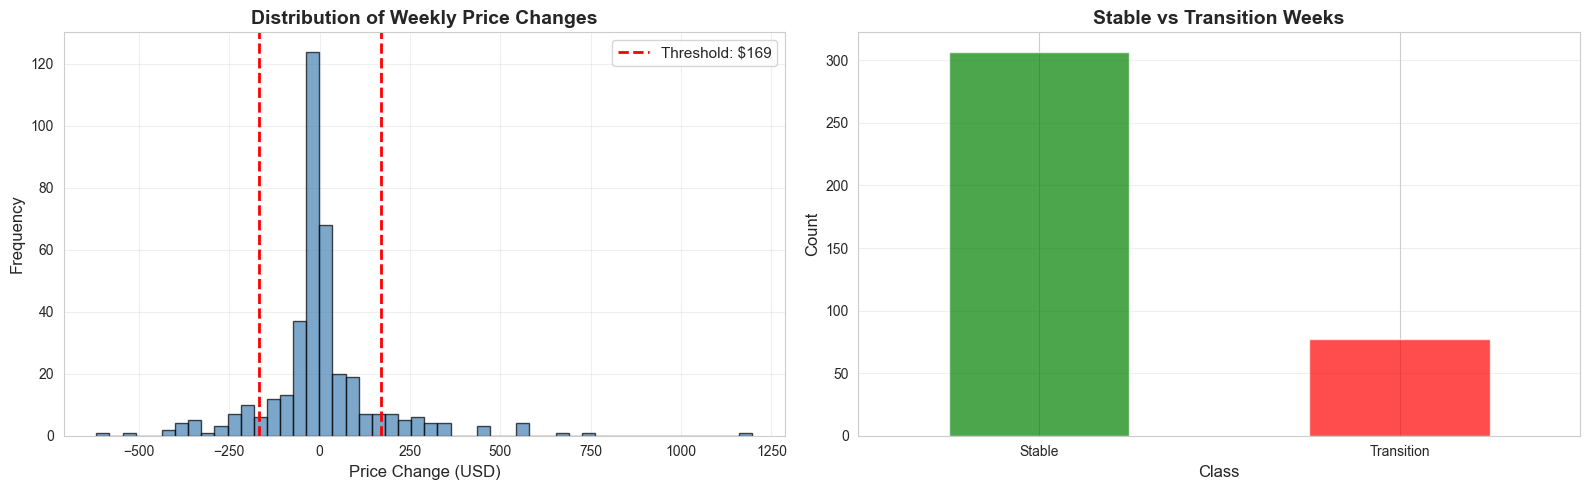


✓ Saved transition distribution plot: data/processed/transition_distribution.png


In [8]:
print("="*80)
print("DEFINING PRICE TRANSITIONS")
print("="*80)

# Analyze price change distribution
abs_changes = df_model['price_change'].abs().dropna()

# Calculate percentiles
percentiles = [50, 70, 80, 90, 95]
threshold_values = {}

print(f"\nAbsolute Price Change Percentiles:")
for p in percentiles:
    val = np.percentile(abs_changes, p)
    threshold_values[p] = val
    print(f"  {p}th percentile: ${val:.2f}")

# Choose threshold (let's use 80th percentile as default)
TRANSITION_THRESHOLD = threshold_values[80]

print(f"\n🎯 Selected Transition Threshold: ${TRANSITION_THRESHOLD:.2f}")
print(f"   (80th percentile of absolute price changes)")

# Create binary transition target
df_model['is_transition'] = (df_model['price_change'].abs() > TRANSITION_THRESHOLD).astype(int)

# Analyze class distribution
transition_counts = df_model['is_transition'].value_counts()
print(f"\n📊 Transition Class Distribution:")
print(f"  Stable (0):     {transition_counts.get(0, 0):3d} ({transition_counts.get(0, 0)/len(df_model)*100:.1f}%)")
print(f"  Transition (1): {transition_counts.get(1, 0):3d} ({transition_counts.get(1, 0)/len(df_model)*100:.1f}%)")

# Visualize distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of price changes
ax1.hist(df_model['price_change'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(x=TRANSITION_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold: ${TRANSITION_THRESHOLD:.0f}')
ax1.axvline(x=-TRANSITION_THRESHOLD, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Price Change (USD)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Weekly Price Changes', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Bar chart of class distribution
transition_counts.plot(kind='bar', ax=ax2, color=['green', 'red'], alpha=0.7)
ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Stable vs Transition Weeks', fontsize=14, fontweight='bold')
ax2.set_xticklabels(['Stable', 'Transition'], rotation=0)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
os.makedirs('data/processed', exist_ok=True)
plt.savefig('data/processed/transition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved transition distribution plot: data/processed/transition_distribution.png")

## Step 3: Feature Selection

In [9]:
print("="*80)
print("FEATURE SELECTION")
print("="*80)

# Get lag features to avoid data leakage
lag_features = [col for col in df_model.columns if '_lag_' in col]
print(f"\nFound {len(lag_features)} lagged features")

# Remove rows with NaN targets
df_clean = df_model.dropna(subset=['price_1w_ahead', 'is_transition']).copy()
print(f"After removing NaN: {len(df_clean)} rows")

# Fill any remaining NaNs in features
df_clean[lag_features] = df_clean[lag_features].fillna(0)

# Use Random Forest to select top features for transition classification
print("\n🔍 Selecting top 20 features for transition classification...")

X_all = df_clean[lag_features]
y_transition = df_clean['is_transition']

# Time-based split for feature selection
split_idx = int(len(df_clean) * 0.8)
X_train_all = X_all.iloc[:split_idx]
y_train_transition = y_transition.iloc[:split_idx]

# Train RF for feature importance
rf_selector = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Handle class imbalance
)
rf_selector.fit(X_train_all, y_train_transition)

# Get top 20 features
feature_importance = pd.Series(
    rf_selector.feature_importances_,
    index=lag_features
).sort_values(ascending=False)

top_20_features = feature_importance.head(20).index.tolist()

print(f"\n📊 Top 20 Features for Transition Classification:")
for i, (feat, imp) in enumerate(feature_importance.head(20).items(), 1):
    print(f"  {i:2d}. {feat:50s} (importance: {imp:.4f})")

print(f"\n✓ Using top 20 features for both classification and regression")

FEATURE SELECTION

Found 217 lagged features
After removing NaN: 383 rows

🔍 Selecting top 20 features for transition classification...

📊 Top 20 Features for Transition Classification:
   1. price_lag_1w_roll_std_8w                           (importance: 0.0485)
   2. price_lag_1w_roll_max_4w                           (importance: 0.0408)
   3. price_lag_1w_roll_std_4w                           (importance: 0.0393)
   4. price_lag_1w_roll_min_4w                           (importance: 0.0370)
   5. price_lag_1w_roll_mean_4w                          (importance: 0.0314)
   6. price_lag_1w                                       (importance: 0.0304)
   7. choke_gibraltar_strait_capacity_container_lag_2w_lag_2w (importance: 0.0271)
   8. price_lag_4w                                       (importance: 0.0268)
   9. price_lag_7w                                       (importance: 0.0261)
  10. price_lag_1w_roll_min_8w                           (importance: 0.0254)
  11. price_lag_3w           

## Step 4: Prepare Train/Test Split

In [10]:
print("="*80)
print("TRAIN/TEST SPLIT")
print("="*80)

# Use only top 20 features
X = df_clean[top_20_features]
y_price = df_clean['price_1w_ahead']
y_transition = df_clean['is_transition']
y_change = df_clean['price_change']

# Time-based split (80/20)
split_idx = int(len(df_clean) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_price_train = y_price.iloc[:split_idx]
y_price_test = y_price.iloc[split_idx:]
y_transition_train = y_transition.iloc[:split_idx]
y_transition_test = y_transition.iloc[split_idx:]
y_change_train = y_change.iloc[:split_idx]
y_change_test = y_change.iloc[split_idx:]

print(f"\nTrain samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {len(top_20_features)}")

print(f"\nTrain date range: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Test date range: {X_test.index.min().date()} to {X_test.index.max().date()}")

# Check class distribution in train/test
print(f"\nTransition class distribution:")
print(f"  Train - Stable: {(y_transition_train == 0).sum()}, Transition: {(y_transition_train == 1).sum()}")
print(f"  Test  - Stable: {(y_transition_test == 0).sum()}, Transition: {(y_transition_test == 1).sum()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Data prepared and scaled")

TRAIN/TEST SPLIT

Train samples: 306
Test samples: 77
Features: 20

Train date range: 2018-01-05 to 2024-01-19
Test date range: 2024-01-26 to 2025-08-08

Transition class distribution:
  Train - Stable: 257, Transition: 49
  Test  - Stable: 49, Transition: 28

✓ Data prepared and scaled


## Step 5: Train Binary Classifier (Step 1)

Train a classifier to predict whether a transition will occur.

In [11]:
print("="*80)
print("STEP 1: BINARY TRANSITION CLASSIFIER")
print("="*80)

# Try multiple classifiers
classifiers = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    )
}

classifier_results = {}

for name, clf in classifiers.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    
    # Train
    clf.fit(X_train_scaled, y_transition_train)
    
    # Predict
    y_pred_class = clf.predict(X_test_scaled)
    y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate
    print(f"\nClassification Report:")
    print(classification_report(y_transition_test, y_pred_class, 
                                target_names=['Stable', 'Transition']))
    
    # Confusion matrix
    cm = confusion_matrix(y_transition_test, y_pred_class)
    print(f"\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"              Stable  Transition")
    print(f"Actual Stable    {cm[0,0]:4d}     {cm[0,1]:4d}")
    print(f"       Trans     {cm[1,0]:4d}     {cm[1,1]:4d}")
    
    # ROC AUC
    roc_auc = roc_auc_score(y_transition_test, y_pred_proba)
    print(f"\nROC AUC: {roc_auc:.4f}")
    
    # Store results
    classifier_results[name] = {
        'model': clf,
        'predictions': y_pred_class,
        'probabilities': y_pred_proba,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }

# Select best classifier based on ROC AUC
best_clf_name = max(classifier_results.items(), key=lambda x: x[1]['roc_auc'])[0]
best_classifier = classifier_results[best_clf_name]['model']
best_pred_class = classifier_results[best_clf_name]['predictions']
best_pred_proba = classifier_results[best_clf_name]['probabilities']

print(f"\n{'='*80}")
print(f"BEST CLASSIFIER: {best_clf_name}")
print(f"ROC AUC: {classifier_results[best_clf_name]['roc_auc']:.4f}")
print(f"{'='*80}")

STEP 1: BINARY TRANSITION CLASSIFIER

Training XGBoost...

Classification Report:
              precision    recall  f1-score   support

      Stable       0.70      0.57      0.63        49
  Transition       0.43      0.57      0.49        28

    accuracy                           0.57        77
   macro avg       0.57      0.57      0.56        77
weighted avg       0.60      0.57      0.58        77


Confusion Matrix:
              Predicted
              Stable  Transition
Actual Stable      28       21
       Trans       12       16

ROC AUC: 0.6108

Training Random Forest...

Classification Report:
              precision    recall  f1-score   support

      Stable       0.70      0.57      0.63        49
  Transition       0.43      0.57      0.49        28

    accuracy                           0.57        77
   macro avg       0.57      0.57      0.56        77
weighted avg       0.60      0.57      0.58        77


Confusion Matrix:
              Predicted
              S

## Step 6: Visualize Classifier Performance

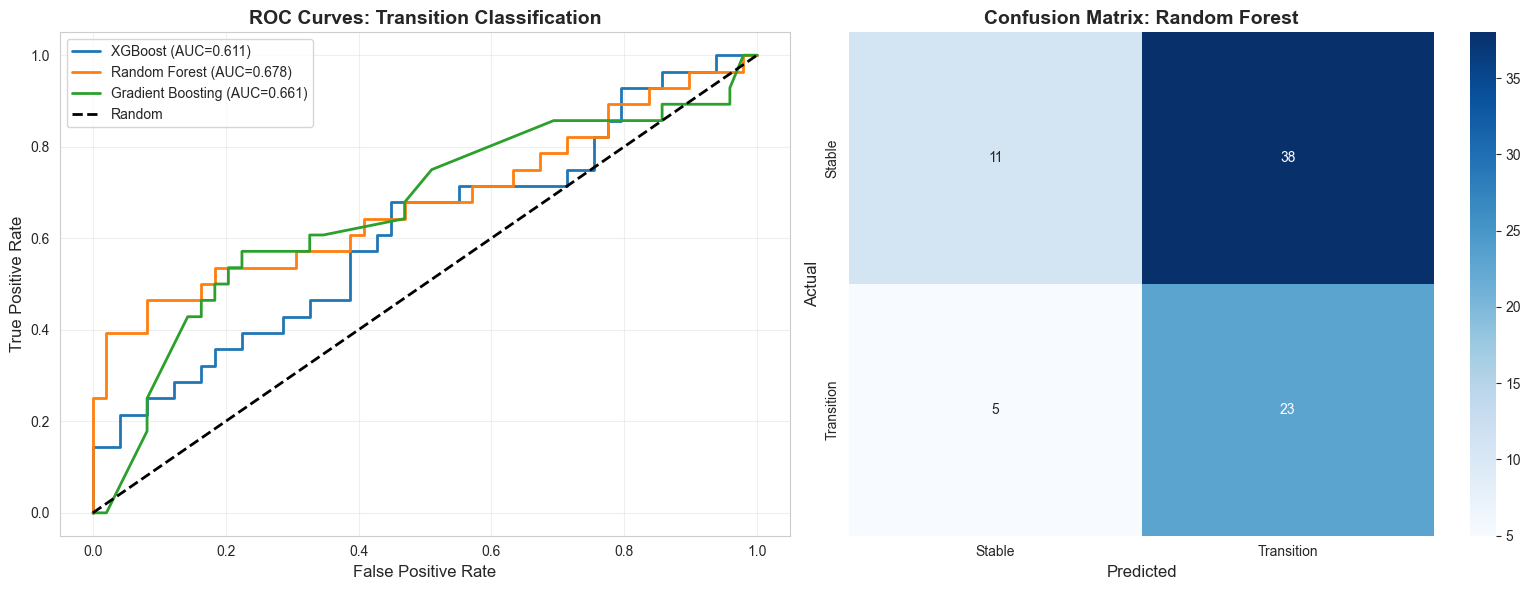

✓ Saved classifier performance plot: data/processed/transition_classifier_performance.png


In [12]:
# ROC curves for all classifiers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot ROC curves
for name, results in classifier_results.items():
    fpr, tpr, _ = roc_curve(y_transition_test, results['probabilities'])
    ax1.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={results['roc_auc']:.3f})")

ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves: Transition Classification', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot confusion matrix for best classifier
cm = classifier_results[best_clf_name]['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Stable', 'Transition'],
            yticklabels=['Stable', 'Transition'])
ax2.set_ylabel('Actual', fontsize=12)
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_title(f'Confusion Matrix: {best_clf_name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/transition_classifier_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved classifier performance plot: data/processed/transition_classifier_performance.png")

## Step 7: Train Regression Models (Step 2)

Train two separate regression models:
1. **Stable model**: Trained only on stable periods
2. **Transition model**: Trained only on transition periods

In [13]:
print("="*80)
print("STEP 2: CONDITIONAL REGRESSION MODELS")
print("="*80)

# Split training data into stable and transition
stable_mask_train = y_transition_train == 0
transition_mask_train = y_transition_train == 1

X_train_stable = X_train_scaled[stable_mask_train]
y_train_stable = y_price_train[stable_mask_train]
X_train_transition = X_train_scaled[transition_mask_train]
y_train_transition = y_price_train[transition_mask_train]

print(f"\nTraining set split:")
print(f"  Stable samples: {len(X_train_stable)}")
print(f"  Transition samples: {len(X_train_transition)}")

# Model 1: Stable regressor (simple model - use last week's price)
print(f"\n{'='*60}")
print("Training STABLE MODEL (Linear Regression)...")
print(f"{'='*60}")

stable_model = LinearRegression()
stable_model.fit(X_train_stable, y_train_stable)
print(f"✓ Stable model trained on {len(X_train_stable)} samples")

# Model 2: Transition regressor (complex model)
print(f"\n{'='*60}")
print("Training TRANSITION MODEL (XGBoost)...")
print(f"{'='*60}")

transition_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
transition_model.fit(X_train_transition, y_train_transition)
print(f"✓ Transition model trained on {len(X_train_transition)} samples")

STEP 2: CONDITIONAL REGRESSION MODELS

Training set split:
  Stable samples: 257
  Transition samples: 49

Training STABLE MODEL (Linear Regression)...
✓ Stable model trained on 257 samples

Training TRANSITION MODEL (XGBoost)...
✓ Transition model trained on 49 samples


## Step 8: Make Hybrid Predictions

Combine classifier and regressors:
- Use classifier to determine regime
- Use appropriate regressor based on predicted regime

In [14]:
print("="*80)
print("HYBRID MODEL PREDICTIONS")
print("="*80)

# Get classifier predictions for test set
predicted_regime = best_pred_class  # 0 = stable, 1 = transition

# Initialize prediction array
y_pred_hybrid = np.zeros(len(X_test))

# Make predictions based on predicted regime
for i in range(len(X_test)):
    if predicted_regime[i] == 0:  # Stable predicted
        y_pred_hybrid[i] = stable_model.predict(X_test_scaled[i:i+1])[0]
    else:  # Transition predicted
        y_pred_hybrid[i] = transition_model.predict(X_test_scaled[i:i+1])[0]

print(f"\n✓ Made predictions for {len(y_pred_hybrid)} test samples")
print(f"  Predicted stable: {(predicted_regime == 0).sum()}")
print(f"  Predicted transition: {(predicted_regime == 1).sum()}")

# Also make predictions using individual models for comparison
y_pred_stable_only = stable_model.predict(X_test_scaled)
y_pred_transition_only = transition_model.predict(X_test_scaled)

HYBRID MODEL PREDICTIONS

✓ Made predictions for 77 test samples
  Predicted stable: 16
  Predicted transition: 61


## Step 9: Evaluate Hybrid Model

In [15]:
print("="*80)
print("HYBRID MODEL EVALUATION")
print("="*80)

# Calculate metrics for hybrid model
rmse_hybrid = np.sqrt(mean_squared_error(y_price_test, y_pred_hybrid))
mae_hybrid = mean_absolute_error(y_price_test, y_pred_hybrid)
mape_hybrid = np.mean(np.abs((y_price_test - y_pred_hybrid) / y_price_test)) * 100
r2_hybrid = r2_score(y_price_test, y_pred_hybrid)

print(f"\n📊 HYBRID MODEL Performance:")
print(f"  RMSE: ${rmse_hybrid:.2f}")
print(f"  MAE:  ${mae_hybrid:.2f}")
print(f"  MAPE: {mape_hybrid:.2f}%")
print(f"  R²:   {r2_hybrid:.4f}")

# Compare to stable-only model
rmse_stable_only = np.sqrt(mean_squared_error(y_price_test, y_pred_stable_only))
print(f"\n📊 STABLE-ONLY MODEL Performance:")
print(f"  RMSE: ${rmse_stable_only:.2f}")

# Compare to transition-only model
rmse_transition_only = np.sqrt(mean_squared_error(y_price_test, y_pred_transition_only))
print(f"\n📊 TRANSITION-ONLY MODEL Performance:")
print(f"  RMSE: ${rmse_transition_only:.2f}")

# Compare to baseline (from notebook 06)
baseline_rmse = 178.89  # Linear Regression from previous notebooks
improvement = ((baseline_rmse - rmse_hybrid) / baseline_rmse) * 100

print(f"\n📈 Comparison to Linear Regression Baseline:")
print(f"  Baseline RMSE: ${baseline_rmse:.2f}")
print(f"  Hybrid RMSE:   ${rmse_hybrid:.2f}")
print(f"  Improvement:   {improvement:.2f}%")

if improvement > 0:
    print(f"\n✅ Hybrid model performs {improvement:.1f}% better than baseline!")
else:
    print(f"\n⚠️  Hybrid model performs {abs(improvement):.1f}% worse than baseline.")

HYBRID MODEL EVALUATION

📊 HYBRID MODEL Performance:
  RMSE: $405.86
  MAE:  $313.61
  MAPE: 13.36%
  R²:   0.8614

📊 STABLE-ONLY MODEL Performance:
  RMSE: $302.15

📊 TRANSITION-ONLY MODEL Performance:
  RMSE: $458.59

📈 Comparison to Linear Regression Baseline:
  Baseline RMSE: $178.89
  Hybrid RMSE:   $405.86
  Improvement:   -126.87%

⚠️  Hybrid model performs 126.9% worse than baseline.


## Step 10: Analyze Performance by Regime

In [16]:
print("="*80)
print("PERFORMANCE BY REGIME (ACTUAL)")
print("="*80)

# Split test set by actual regime
actual_stable_mask = y_transition_test == 0
actual_transition_mask = y_transition_test == 1

# Stable periods
if actual_stable_mask.sum() > 0:
    y_test_stable = y_price_test[actual_stable_mask]
    y_pred_stable = y_pred_hybrid[actual_stable_mask]
    rmse_stable_regime = np.sqrt(mean_squared_error(y_test_stable, y_pred_stable))
    
    print(f"\n📊 Performance during STABLE periods:")
    print(f"   Samples: {actual_stable_mask.sum()}")
    print(f"   RMSE: ${rmse_stable_regime:.2f}")

# Transition periods
if actual_transition_mask.sum() > 0:
    y_test_transition = y_price_test[actual_transition_mask]
    y_pred_transition = y_pred_hybrid[actual_transition_mask]
    rmse_transition_regime = np.sqrt(mean_squared_error(y_test_transition, y_pred_transition))
    
    print(f"\n📊 Performance during TRANSITION periods:")
    print(f"   Samples: {actual_transition_mask.sum()}")
    print(f"   RMSE: ${rmse_transition_regime:.2f}")

print(f"\n" + "="*80)

PERFORMANCE BY REGIME (ACTUAL)

📊 Performance during STABLE periods:
   Samples: 49
   RMSE: $360.10

📊 Performance during TRANSITION periods:
   Samples: 28
   RMSE: $475.44



## Step 11: Visualize Hybrid Predictions

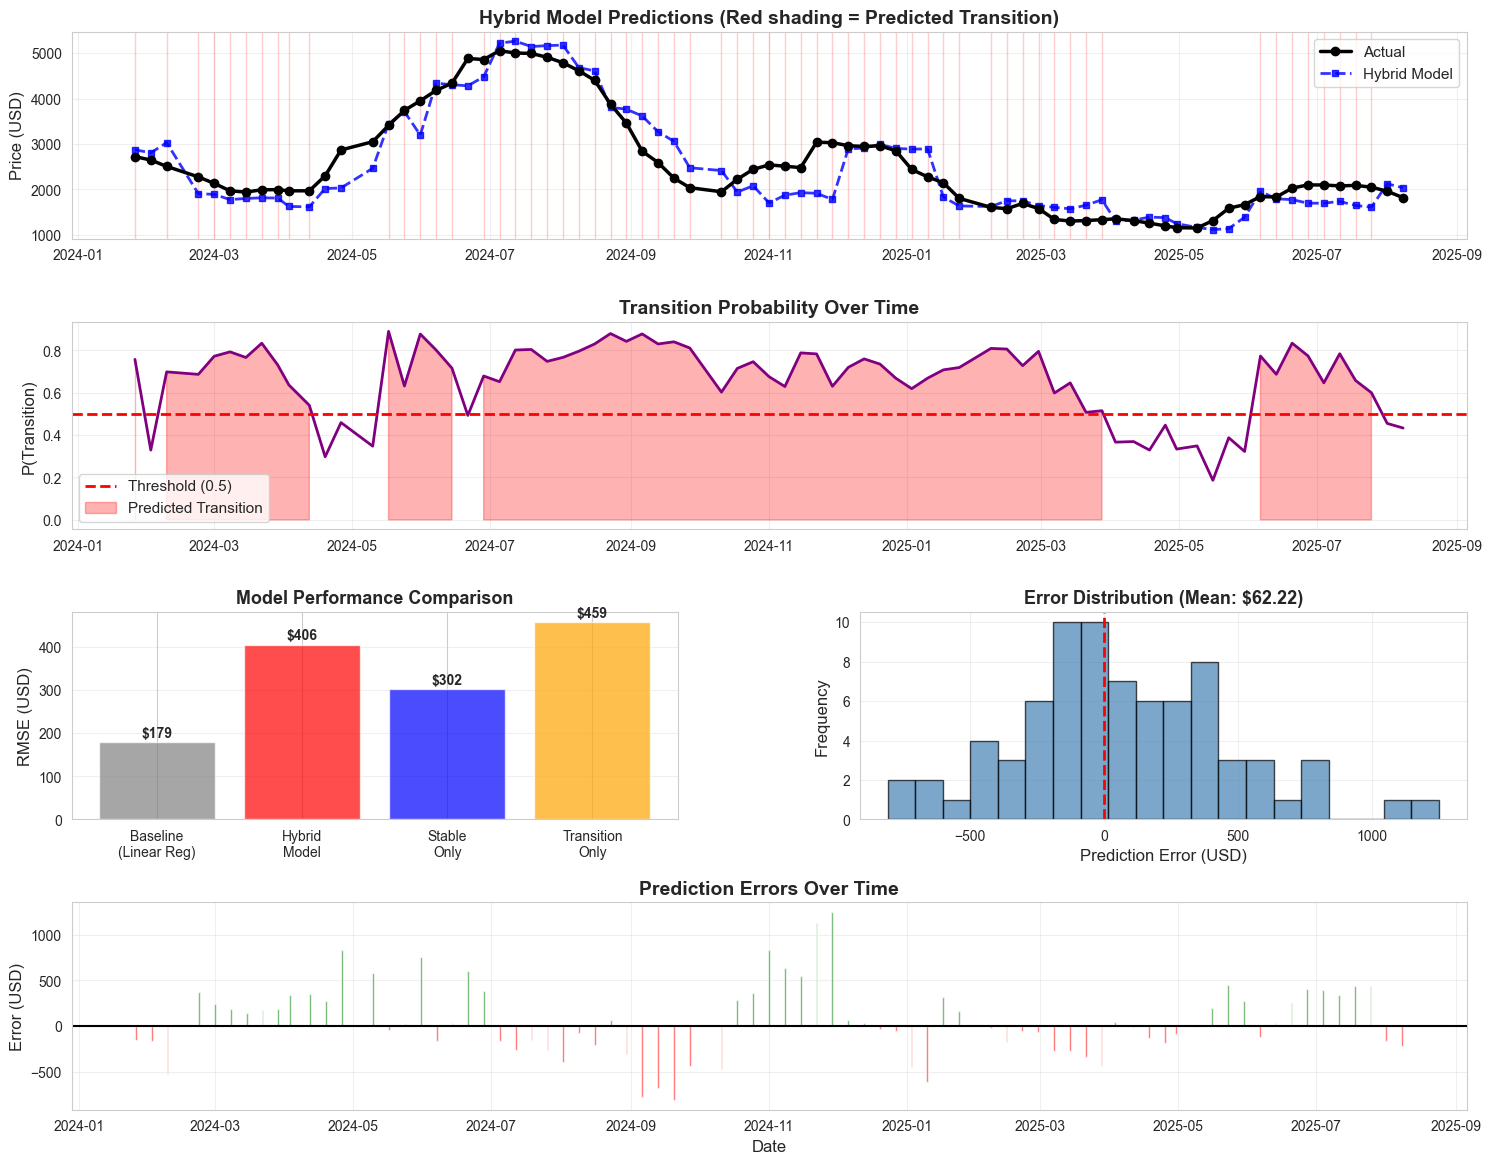


✓ Saved visualization: data/processed/hybrid_model_comprehensive.png


In [17]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.3)

test_dates = X_test.index

# Plot 1: Predictions with regime highlighting
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates, y_price_test.values, 'o-', label='Actual', 
         color='black', linewidth=2.5, markersize=6, zorder=5)
ax1.plot(test_dates, y_pred_hybrid, 's--', label='Hybrid Model', 
         color='blue', linewidth=2, markersize=5, alpha=0.8)

# Highlight predicted transitions
transition_dates = test_dates[predicted_regime == 1]
for date in transition_dates:
    ax1.axvspan(date, date, alpha=0.2, color='red')

ax1.set_title('Hybrid Model Predictions (Red shading = Predicted Transition)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.legend(loc='best', fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Classifier probabilities
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(test_dates, best_pred_proba, linewidth=2, color='purple')
ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax2.fill_between(test_dates, 0, best_pred_proba, 
                 where=(best_pred_proba > 0.5), alpha=0.3, color='red', label='Predicted Transition')
ax2.set_title('Transition Probability Over Time', fontsize=14, fontweight='bold')
ax2.set_ylabel('P(Transition)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# Plot 3: Model comparison
ax3 = fig.add_subplot(gs[2, 0])
models = ['Baseline\n(Linear Reg)', 'Hybrid\nModel', 'Stable\nOnly', 'Transition\nOnly']
rmses = [baseline_rmse, rmse_hybrid, rmse_stable_only, rmse_transition_only]
colors_bar = ['gray', 'green' if improvement > 0 else 'red', 'blue', 'orange']
bars = ax3.bar(models, rmses, color=colors_bar, alpha=0.7)
ax3.set_ylabel('RMSE (USD)', fontsize=12)
ax3.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Add values on bars
for bar, val in zip(bars, rmses):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 5, f'${val:.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Prediction errors
ax4 = fig.add_subplot(gs[2, 1])
errors = y_price_test.values - y_pred_hybrid
ax4.hist(errors, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Prediction Error (USD)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title(f'Error Distribution (Mean: ${errors.mean():.2f})', 
              fontsize=13, fontweight='bold')
ax4.grid(alpha=0.3)

# Plot 5: Error over time
ax5 = fig.add_subplot(gs[3, :])
colors_error = ['red' if e < 0 else 'green' for e in errors]
ax5.bar(test_dates, errors, color=colors_error, alpha=0.7)
ax5.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax5.set_title('Prediction Errors Over Time', fontsize=14, fontweight='bold')
ax5.set_ylabel('Error (USD)', fontsize=12)
ax5.set_xlabel('Date', fontsize=12)
ax5.grid(alpha=0.3)

plt.savefig('data/processed/hybrid_model_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization: data/processed/hybrid_model_comprehensive.png")

## Step 12: Save Models and Results

In [18]:
# Save models
import pickle

models_to_save = {
    'classifier': best_classifier,
    'stable_regressor': stable_model,
    'transition_regressor': transition_model,
    'scaler': scaler
}

with open('data/processed/hybrid_models.pkl', 'wb') as f:
    pickle.dump(models_to_save, f)
print("✓ Saved models to: data/processed/hybrid_models.pkl")

# Save results summary
results_summary = {
    'model': 'Two-Step Hybrid',
    'transition_threshold': float(TRANSITION_THRESHOLD),
    'classifier': best_clf_name,
    'classifier_roc_auc': float(classifier_results[best_clf_name]['roc_auc']),
    'n_features': len(top_20_features),
    'top_features': top_20_features,
    'hybrid_rmse': float(rmse_hybrid),
    'hybrid_mae': float(mae_hybrid),
    'hybrid_mape': float(mape_hybrid),
    'hybrid_r2': float(r2_hybrid),
    'stable_only_rmse': float(rmse_stable_only),
    'transition_only_rmse': float(rmse_transition_only),
    'baseline_rmse': float(baseline_rmse),
    'improvement_pct': float(improvement),
    'train_stable_samples': int((y_transition_train == 0).sum()),
    'train_transition_samples': int((y_transition_train == 1).sum()),
    'test_stable_samples': int((y_transition_test == 0).sum()),
    'test_transition_samples': int((y_transition_test == 1).sum())
}

with open('data/processed/hybrid_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("✓ Saved results to: data/processed/hybrid_results.json")

# Save predictions
predictions_df = pd.DataFrame({
    'Date': test_dates,
    'Actual': y_price_test.values,
    'Predicted': y_pred_hybrid,
    'Error': errors,
    'Predicted_Regime': predicted_regime,
    'Actual_Regime': y_transition_test.values,
    'Transition_Probability': best_pred_proba
})
predictions_df.to_csv('data/processed/hybrid_predictions.csv', index=False)
print("✓ Saved predictions to: data/processed/hybrid_predictions.csv")

✓ Saved models to: data/processed/hybrid_models.pkl
✓ Saved results to: data/processed/hybrid_results.json
✓ Saved predictions to: data/processed/hybrid_predictions.csv


## Step 13: Key Insights and Business Value

### Model Interpretation

The Two-Step Hybrid Model provides:

1. **Transition Detection**: Identifies when contract renewals are likely
2. **Conditional Prediction**: Uses specialized models for each regime
3. **Probability Scores**: Provides confidence in transition predictions

### Business Applications

1. **Contract Timing**: High transition probability signals optimal negotiation windows
2. **Risk Management**: Anticipate price jumps before they occur
3. **Planning**: Separate stable periods (easy planning) from volatile periods
4. **Budgeting**: More accurate forecasts by accounting for regime changes

### Advantages Over Single Model

- **Explicit regime modeling**: Directly addresses contract cycles
- **Better interpretability**: Clear separation of "when" vs "how much"
- **Specialized training**: Each model optimized for its task
- **Actionable insights**: Transition probabilities guide decisions

### When This Model Excels

- If classifier ROC AUC > 0.75: Successfully detects transitions
- If hybrid RMSE < baseline: Overall improvement in predictions
- If transition regime RMSE is reasonable: Captures price jumps well

In [19]:
print("="*80)
print("TWO-STEP HYBRID MODEL COMPLETE")
print("="*80)
print(f"\nClassifier: {best_clf_name} (ROC AUC: {classifier_results[best_clf_name]['roc_auc']:.4f})")
print(f"Hybrid RMSE: ${rmse_hybrid:.2f} (R² = {r2_hybrid:.4f})")
print(f"Improvement over baseline: {improvement:.2f}%")
print(f"\nAll outputs saved to data/processed/")

TWO-STEP HYBRID MODEL COMPLETE

Classifier: Random Forest (ROC AUC: 0.6778)
Hybrid RMSE: $405.86 (R² = 0.8614)
Improvement over baseline: -126.87%

All outputs saved to data/processed/
